# Multi-Fish Cohort `[56h]` + `[56g]`

This notebook aggregates already processed fish and produces cohort-level versions of:
- `[56h]` (BPI + condensed ipsi/contra traces)
- `[56g]` (BPI vs activity diagnostics)

Configured fish for now:
- `L395_f11` (`owner='Danin'`)
- `L396_f01` (`owner='Matilde'`)
- `L396_f04` (`owner='Matilde'`)


## Cohort Onboarding

This notebook is a downstream cohort analysis notebook, not a raw-data entrypoint. In plain English, a **cohort** is a group of already processed fish. This notebook compares them by reusing fish-level outputs from the single-fish pipeline rather than redoing raw functional imaging, anatomy registration, or HCR discovery from scratch.

Each cohort fish must already have completed single-fish outputs under its own fish folder before you run this notebook.

## Fish-spec input contract
- Each cohort entry needs an `owner` and a `fish_id`.
- In local mode, the code resolves fish directories in this order: `DATA_ROOT/<fish_id>`, `DATA_ROOT/<owner>/<fish_id>`, then `DATA_ROOT/<owner>/Microscopy/<fish_id>`.

## What the cohort build expects to find from each fish
- Response/BPI tables that summarize which ROIs or identified cells responded and how they were classified.
- Trace caches or per-cell response summaries derived from the fish-level Suite2p outputs.
- The pooled-source tables for the cohort analogue of `[53a]`, or the single-fish outputs needed to rebuild those summaries.
- Fish-level metadata and experiment-log files when stimulus aggregation still depends on them.

In practice, the cohort build reads each fish's processed analysis area, including fish-level pair tables, Suite2p outputs, registration metadata, and stimulus logs. It does not promise support for starting from raw imaging folders alone.

## What this notebook writes
- Pooled comparison figures across fish.
- Cohort cache tables saved under the cohort output directory.
- Cohort trace payloads used by the trace-focused cohort figures.

The onboarding cell answers what this notebook is for and what must already exist. The later stage markdown cells continue to explain what each cohort stage does and how to interpret its outputs.


### [cfg] Cohort configuration
This stage-specific note picks up after the onboarding overview above and covers the cohort run configuration only.

**What goes in:** The list of fish to aggregate and the cohort-level build settings.

**What this does:** Defines which processed fish will be combined and resolves the shared cohort output context.

**What comes out:** A cohort configuration and a stable output directory for all downstream cohort figures.

**How to interpret it:** This cell sets the cohort scope; every later result depends on which fish are included here.

**What good looks like:** The intended fish list is explicit, the cohort output root resolves cleanly, and downstream stages reuse the same context instead of redefining it.


In [1]:
# [cfg] Imports + cohort configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from codeants_2pf_hcr import (
    CohortBuildConfig,
    cohort_cache_paths,
    resolve_cohort_context_stage,
)

COHORT_RECOMPUTE_CACHE = False  # Set True to force cohort cache rebuild.

COHORT_BUILD_CONFIG = CohortBuildConfig(
    data_mode="local",
    default_gene_order=("sst1.1", "sst1.2", "npy", "tac3b", "pth2", "cfos"),
    force_build=COHORT_RECOMPUTE_CACHE,
    skip_build_if_cached=not COHORT_RECOMPUTE_CACHE,
)

cohort_context = resolve_cohort_context_stage(COHORT_BUILD_CONFIG)
globals().update(cohort_context["bindings"])


### [helpers] Cohort build/cache owner API bindings
**What goes in:** The package-level cohort API.

**What this does:** Imports the owner functions that build, load, and save cohort-level cache artifacts.

**What comes out:** Thin notebook bindings to the cohort build machinery.

**How to interpret it:** This keeps business logic in the package and the notebook focused on orchestration.

**What good looks like:** The notebook can call the cohort owner API directly without reimplementing cache logic inline.


In [2]:
# [helpers] Cohort build/cache owner API bindings
from codeants_2pf_hcr import (
    build_cohort_outputs_stage,
    load_cohort_outputs_from_disk,
    save_cohort_outputs_to_disk,
)


### [cohort-build] Aggregate fish-level outputs into cohort caches
**What goes in:** The configured fish list and each fish's previously generated single-fish outputs.

**What this does:** Loads the fish-level tables and trace summaries, then aggregates them into shared cohort caches.

**What comes out:** Cohort tables, trace payloads, and fish summary metadata used by the figure cells below.

**How to interpret it:** This is the handoff from single-fish authority to cohort-level comparison.

**What good looks like:** All expected fish appear in the cohort summary, failed fish are explicit, and later cohort figures can run without silently recomputing semantics.


In [3]:
# [cohort-build] Load each fish and aggregate trial/cell/trace data
cohort_build_result = build_cohort_outputs_stage(COHORT_BUILD_CONFIG)
globals().update(cohort_build_result["bindings"])
if isinstance(globals().get("cohort_fish_summary_df"), pd.DataFrame) and (not globals()["cohort_fish_summary_df"].empty):
    display(globals()["cohort_fish_summary_df"])


[cache] loaded: cohort_bpi_cells_df, cohort_bpi_trials_df, cohort_fish_summary_df, cohort_mode_durations, cohort_mode_event_counts, cohort_results_stim_ipsi_contra, cohort_results_stim_ipsi_contra_by_fish, cohort_results_stim_ipsi_contra_per_cell_by_fish, cohort_stim_summary_df, cohort_tvec, diameter_filter_summary_df, diameters_df, func_anat_offsets_df, hcr_offsets_df, ncc_curves_df, thresholds_df
[cohort-build] Reusing cached cohort outputs from disk; skipping fish rebuild.


,owner,fish_id,fish_dir,ok,n_pairs_in,n_pairs_used,n_pairs_with_side,n_trial_rows,n_trace_segments,fps,notes
0,Matilde,L395_f11,/Users/ddharmap/dataProcessing/2p_HCR/analysis...,True,33,31,31,744,624,2.0,ok
1,Matilde,L396_f01,/Users/ddharmap/dataProcessing/2p_HCR/analysis...,True,8,8,8,192,256,2.0,ok
2,Matilde,L396_f03,/Users/ddharmap/dataProcessing/2p_HCR/analysis...,True,23,21,21,504,784,2.0,ok
3,Matilde,L396_f04,/Users/ddharmap/dataProcessing/2p_HCR/analysis...,True,17,17,16,384,384,2.0,ok


### [53a-cohort] Cohort registration and segmentation summary
**What goes in:** Cached cohort tables that pool the same kinds of evidence shown in single-fish `[53a]`.

**What this does:** Summarizes whether the registration and segmentation checks look consistent across fish rather than for only one example.

**What comes out:** A cohort analogue of the single-fish registration QA figure.

**How to interpret it:** The goal is not to erase fish-to-fish variation, but to ask whether the overall cohort still supports credible cross-modal matching.

**What good looks like:** Most fish contribute curves, sizes, and offsets in the same broad range, without one fish dominating the cohort or pushing the pooled distributions into clearly implausible regimes.


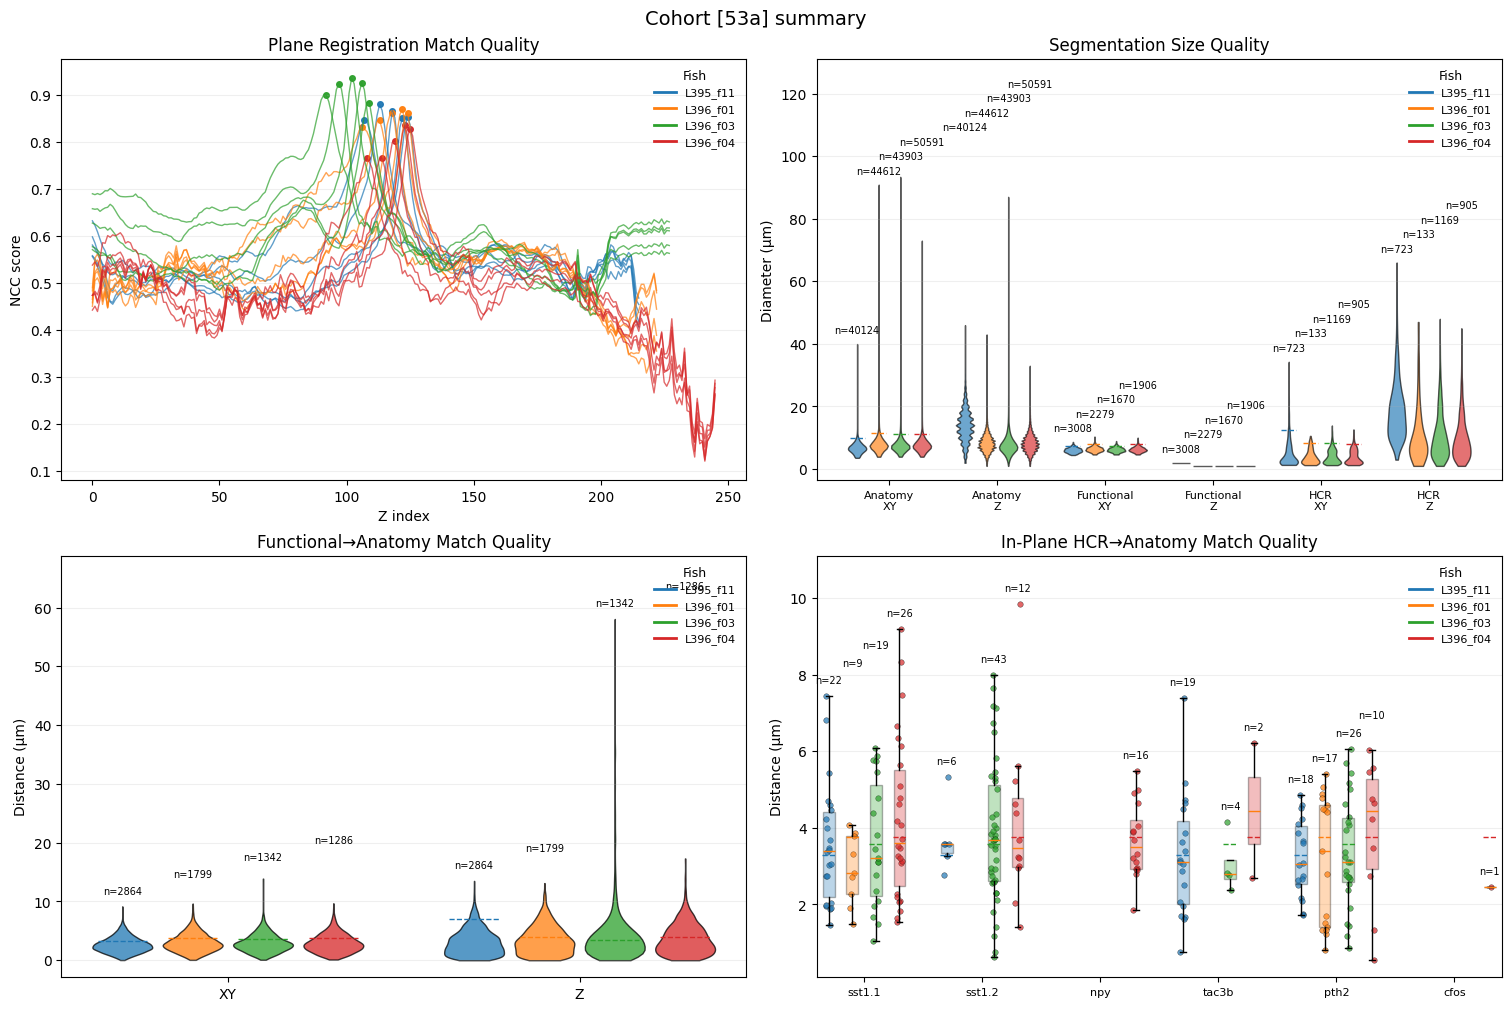

[53a-cohort] saved: /Users/ddharmap/dataProcessing/2p_HCR/analysis/midThesis/cohort_outputs/multi_fish_56h_56g/cohort_53a_summary.png
[53a-cohort] saved: /Users/ddharmap/dataProcessing/2p_HCR/analysis/midThesis/cohort_outputs/multi_fish_56h_56g/cohort_53a_summary.pdf
[53a-cohort] representative median HCR→anatomy XY offset across fish (median of fish medians): 3.34 um (fish=4, pairs=250)
[53a-cohort] representative median functional→anatomy XY offset across fish (median of fish medians): 2.74 um (fish=4, pairs=7291)


In [4]:
# [53a-cohort] Cohort 2x2 [53a]-analogue summary figure from cached cohort tables
from codeants_2pf_hcr.plots.qa import render_cohort_53a_summary

_cohort_cache_paths = cohort_cache_paths(COHORT_OUTDIR)
_ncc_curves_df = pd.read_csv(_cohort_cache_paths["cohort_53a_ncc_curves_csv"])
_diameters_df = pd.read_csv(_cohort_cache_paths["cohort_53a_diameters_csv"])
_diameter_filter_summary_df = pd.read_csv(_cohort_cache_paths["cohort_53a_diameter_filter_summary_csv"])
_func_anat_offsets_df = pd.read_csv(_cohort_cache_paths["cohort_53a_func_anat_offsets_csv"])
_hcr_offsets_df = pd.read_csv(_cohort_cache_paths["cohort_53a_hcr_offsets_csv"])
_thresholds_df = pd.read_csv(_cohort_cache_paths["cohort_53a_thresholds_csv"])

fig_53a_cohort = render_cohort_53a_summary(
    ncc_curves_df=_ncc_curves_df,
    diameters_df=_diameters_df,
    diameter_filter_summary_df=_diameter_filter_summary_df,
    func_anat_offsets_df=_func_anat_offsets_df,
    hcr_offsets_df=_hcr_offsets_df,
    thresholds_df=_thresholds_df,
    gene_order=GENE_ORDER,
    gene_colors=GENE_COLORS,
)

cohort_53a_png = COHORT_OUTDIR / "cohort_53a_summary.png"
cohort_53a_pdf = COHORT_OUTDIR / "cohort_53a_summary.pdf"
fig_53a_cohort.savefig(cohort_53a_png, dpi=300, bbox_inches="tight")
fig_53a_cohort.savefig(cohort_53a_pdf, dpi=300, bbox_inches="tight")
display(fig_53a_cohort)
plt.close(fig_53a_cohort)
print(f"[53a-cohort] saved: {cohort_53a_png}")
print(f"[53a-cohort] saved: {cohort_53a_pdf}")
_cohort_hcr_xy_med = pd.to_numeric(_thresholds_df.get("hcr_xy_median_of_fish_medians_um", pd.Series([np.nan])), errors="coerce").iloc[0]
_cohort_hcr_xy_n_fish = int(pd.to_numeric(_thresholds_df.get("hcr_xy_n_fish", pd.Series([0])), errors="coerce").fillna(0).iloc[0])
_cohort_hcr_xy_n_pairs = int(pd.to_numeric(_thresholds_df.get("hcr_xy_n_pairs", pd.Series([0])), errors="coerce").fillna(0).iloc[0])
_cohort_func_xy_med = pd.to_numeric(_thresholds_df.get("func_anat_xy_median_of_fish_medians_um", pd.Series([np.nan])), errors="coerce").iloc[0]
_cohort_func_xy_n_fish = int(pd.to_numeric(_thresholds_df.get("func_anat_xy_n_fish", pd.Series([0])), errors="coerce").fillna(0).iloc[0])
_cohort_func_xy_n_pairs = int(pd.to_numeric(_thresholds_df.get("func_anat_xy_n_pairs", pd.Series([0])), errors="coerce").fillna(0).iloc[0])
if np.isfinite(_cohort_hcr_xy_med):
    print(
        f"[53a-cohort] representative median HCR→anatomy XY offset across fish (median of fish medians): "
        f"{float(_cohort_hcr_xy_med):.2f} um (fish={_cohort_hcr_xy_n_fish}, pairs={_cohort_hcr_xy_n_pairs})"
    )
else:
    print("[53a-cohort] representative median HCR→anatomy XY offset across fish: unavailable")
if np.isfinite(_cohort_func_xy_med):
    print(
        f"[53a-cohort] representative median functional→anatomy XY offset across fish (median of fish medians): "
        f"{float(_cohort_func_xy_med):.2f} um (fish={_cohort_func_xy_n_fish}, pairs={_cohort_func_xy_n_pairs})"
    )
else:
    print("[53a-cohort] representative median functional→anatomy XY offset across fish: unavailable")


### [56h-cohort] Cohort stimulus-locked traces by fish
**What goes in:** The cohort trace cache and the response-aware cohort ROI table.

**What this does:** Shows whether the gene-level stimulus responses seen in single fish recur across the cohort.

**What comes out:** Per-gene stimulus traces with fish-level overlays.

**How to interpret it:** Each gene panel should be read as a consistency check across fish, not only as a pooled average.

**What good looks like:** Multiple fish show comparable response structure for the same gene, even if the amplitudes differ.


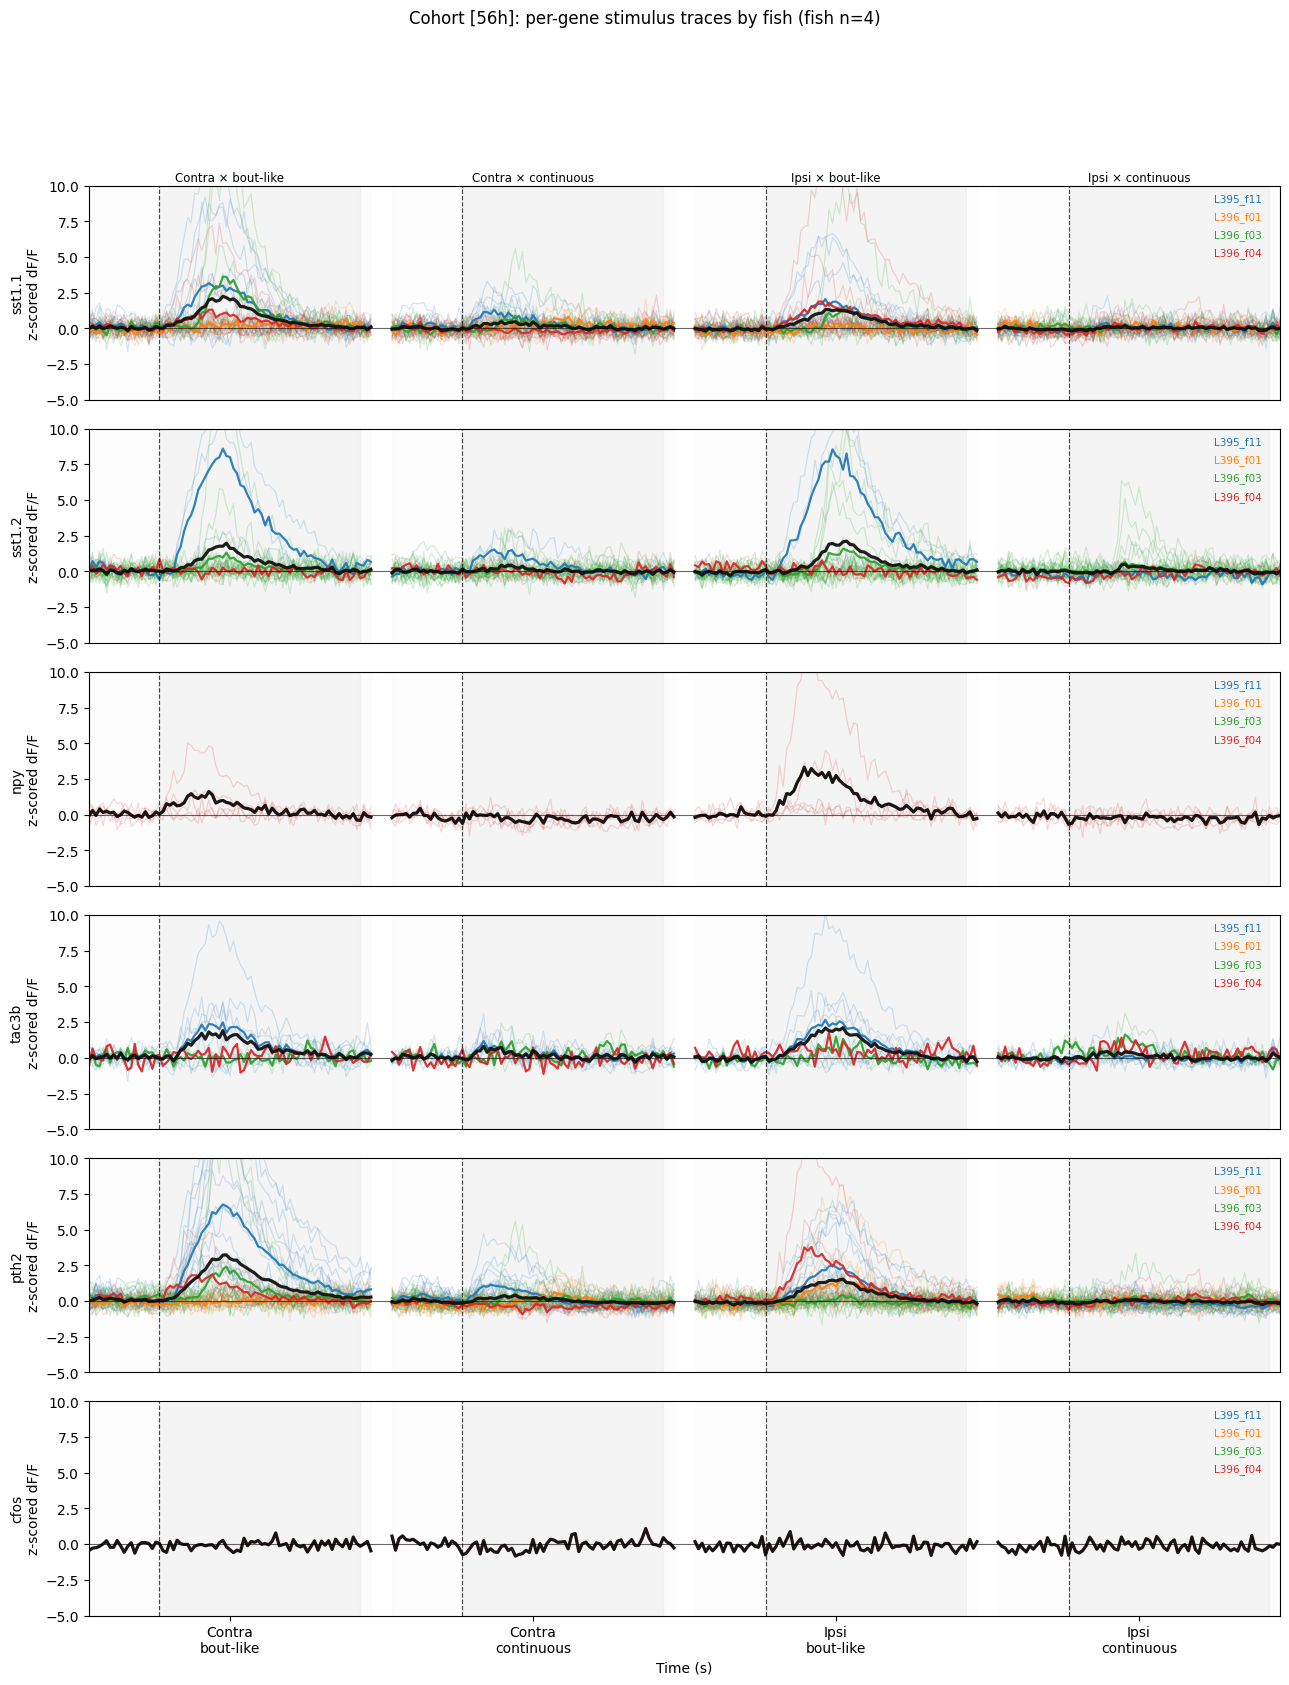

In [5]:
# [56h-cohort] Cohort per-gene traces by fish (from [56h]-style outputs)
from codeants_2pf_hcr.plots.analysis import render_cohort_56h_by_fish
from codeants_2pf_hcr import count_trace_genes, load_cohort_analysis_state

state_bindings = {}
if not all(k in globals() for k in [
    "cohort_bpi_cells_df",
    "cohort_results_stim_ipsi_contra",
    "cohort_results_stim_ipsi_contra_by_fish",
    "cohort_results_stim_ipsi_contra_per_cell_by_fish",
    "cohort_tvec",
]):
    state_bindings = load_cohort_analysis_state(
        COHORT_BUILD_CONFIG,
        outdir=COHORT_OUTDIR,
        load_tables=True,
        load_trace_cache=True,
        load_cohort_53a_tables=False,
        verbose=True,
    )["bindings"]

cell_df = state_bindings.get("cohort_bpi_cells_df", cohort_bpi_cells_df)
results = state_bindings.get("cohort_results_stim_ipsi_contra", cohort_results_stim_ipsi_contra)
results_by_fish = state_bindings.get("cohort_results_stim_ipsi_contra_by_fish", cohort_results_stim_ipsi_contra_by_fish)
results_per_cell_by_fish = state_bindings.get("cohort_results_stim_ipsi_contra_per_cell_by_fish", cohort_results_stim_ipsi_contra_per_cell_by_fish)
tvec = state_bindings.get("cohort_tvec", cohort_tvec)
mode_durations = state_bindings.get("cohort_mode_durations", cohort_mode_durations)
cohort_fish_summary_local = state_bindings.get("cohort_fish_summary_df", cohort_fish_summary_df)

if not isinstance(results_per_cell_by_fish, dict) or (count_trace_genes(results_per_cell_by_fish, PLOT_ORDER, nested=True) == 0):
    raise RuntimeError("cohort_results_stim_ipsi_contra_per_cell_by_fish missing or stale; rerun [cohort-build] with FORCE_COHORT_BUILD=True.")

render_56h = render_cohort_56h_by_fish(
    cell_df=cell_df,
    results=results,
    results_by_fish=results_by_fish,
    results_per_cell_by_fish=results_per_cell_by_fish,
    tvec=tvec,
    mode_durations=mode_durations,
    cohort_fish_summary_df=cohort_fish_summary_local,
    gene_order=GENE_ORDER,
    gene_colors=GENE_COLORS,
    plot_order=PLOT_ORDER,
    plot_titles=PLOT_TITLES,
    min_segments=MIN_SEGMENTS,
    min_cells=MIN_CELLS,
    out_path=COHORT_OUTDIR / "cohort_56h_per_gene_by_fish.png",
)
FIG_56H_COHORT_LAST = render_56h["fig"]
try:
    FIG_56H_COHORT_LAST.canvas.draw()
    FIG_56H_COHORT_RGBA = np.asarray(FIG_56H_COHORT_LAST.canvas.buffer_rgba()).copy()
except Exception:
    FIG_56H_COHORT_RGBA = None
plt.show()


### [56g-cohort] Cohort tuning-versus-activity diagnostics
**What goes in:** The cohort BPI/activity table.

**What this does:** Tests at cohort scale whether apparent tuning remains distinct from a simple low-activity explanation.

**What comes out:** A cohort version of the four-panel `[56g]` diagnostic.

**How to interpret it:** This is the cohort stress test for tuning claims.

**What good looks like:** Tuned cells remain separable from low-activity cells across the cohort rather than only in one standout fish.


interpretation,gene,near-zero BPI + high activity,near-zero BPI + low activity,non-zero BPI
0,npy,1,1,2
1,pth2,1,1,28
2,sst1.1,3,3,15
3,sst1.2,1,0,13
4,tac3b,1,1,5


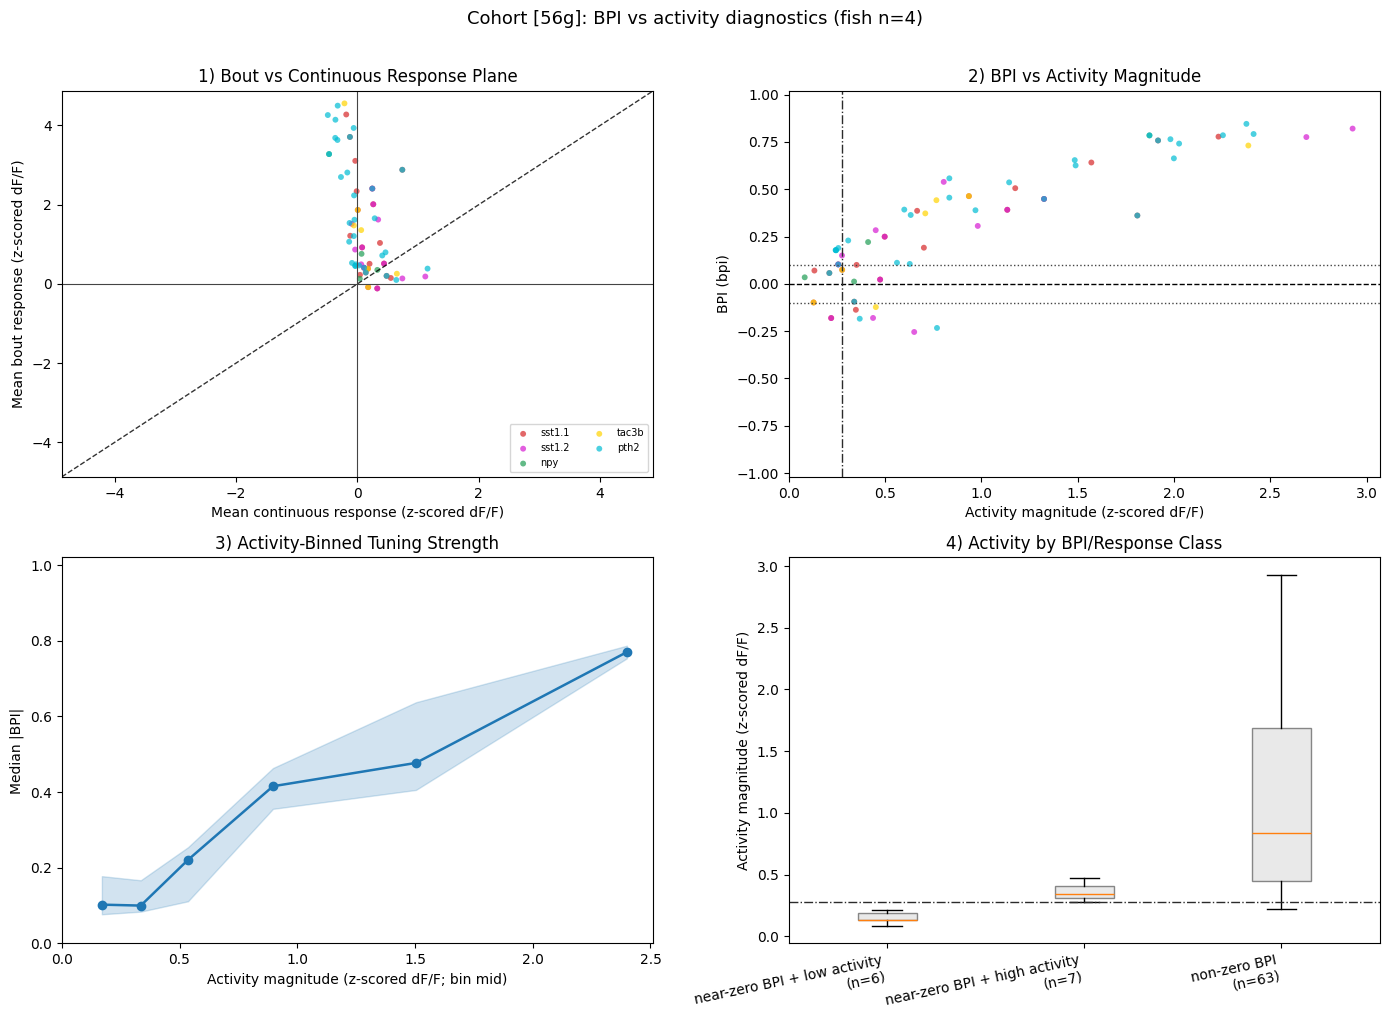

In [6]:
# [56g-cohort] Cohort BPI/activity diagnostics (2x2)
from codeants_2pf_hcr.plots.analysis import render_cohort_56g_diagnostics
from codeants_2pf_hcr import load_cohort_analysis_state

state_bindings = {}
if "cohort_bpi_cells_df" not in globals():
    state_bindings = load_cohort_analysis_state(
        COHORT_BUILD_CONFIG,
        outdir=COHORT_OUTDIR,
        load_tables=True,
        load_trace_cache=False,
        load_cohort_53a_tables=False,
        verbose=True,
    )["bindings"]

df_56g = state_bindings.get("cohort_bpi_cells_df", cohort_bpi_cells_df)
cohort_fish_summary_local = state_bindings.get("cohort_fish_summary_df", cohort_fish_summary_df)
render_56g = render_cohort_56g_diagnostics(
    df=df_56g,
    gene_order=GENE_ORDER,
    gene_colors=GENE_COLORS,
    cohort_fish_summary_df=cohort_fish_summary_local,
    out_path=COHORT_OUTDIR / "cohort_56g.png",
)
cohort_bpi_activity_df = render_56g["cohort_bpi_activity_df"].copy()
cohort_bpi_activity_bins_df = render_56g["cohort_bpi_activity_bins_df"].copy()
FIG_56G_COHORT_LAST = render_56g["fig"]
try:
    FIG_56G_COHORT_LAST.canvas.draw()
    FIG_56G_COHORT_RGBA = np.asarray(FIG_56G_COHORT_LAST.canvas.buffer_rgba()).copy()
except Exception:
    FIG_56G_COHORT_RGBA = None
try:
    cohort_bpi_activity_breakdown_df = (
        cohort_bpi_activity_df.groupby(["gene", "interpretation"]).size().unstack(fill_value=0).reset_index()
    )
    display(cohort_bpi_activity_breakdown_df)
except Exception:
    pass
plt.show()


### [cohort-auc] Cohort motion-window AUC comparisons
**What goes in:** Cohort-wide AUC point and count tables derived from the single-fish response annotations.

**What this does:** Compares stimulus-driven response strength across direction and gene-defined groups at cohort scale.

**What comes out:** Cohort AUC panels for population-wide and marker-specific responses.

**How to interpret it:** This figure asks whether response magnitude and directionality stay separable across the cohort.

**What good looks like:** Population-wide and marker-specific panels tell a compatible story, with gene-level patterns that are visible across more than one fish.


/Users/ddharmap/gitRepo/codeANTs/src/codeants_2pf_hcr/plots/analysis.py:766: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.06, 0, 1, 0.97])


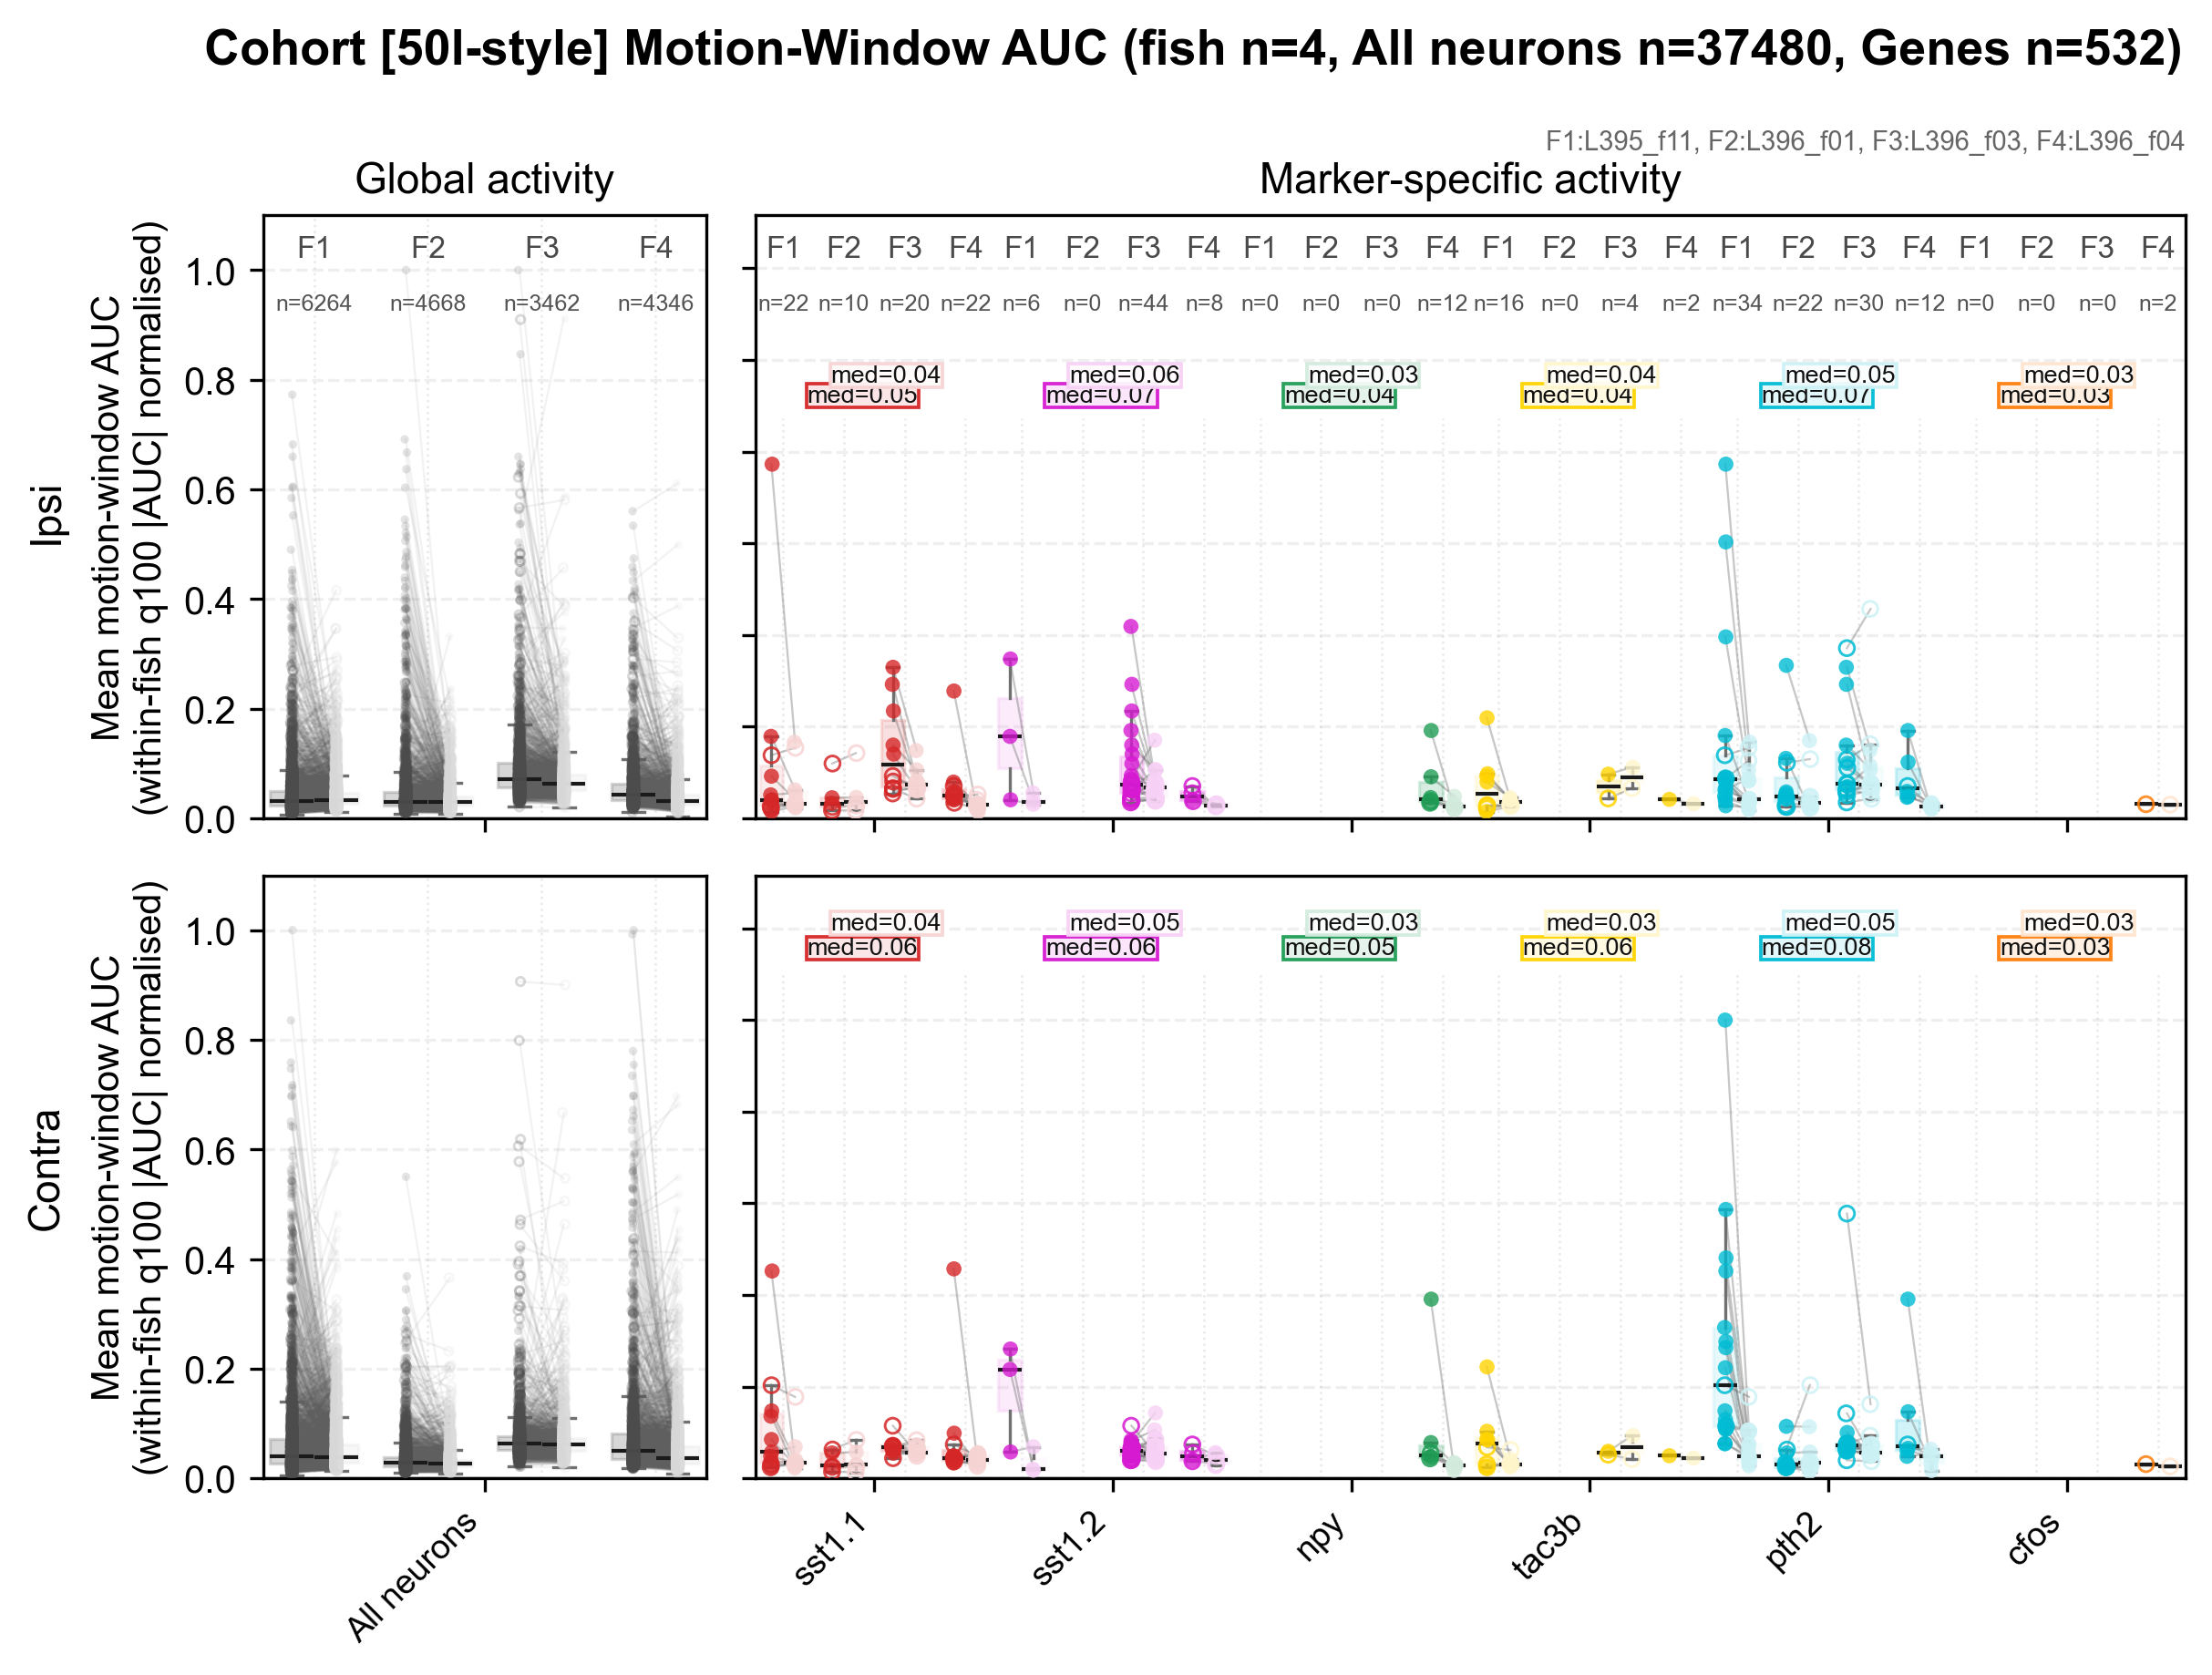

In [7]:
# [cohort-auc] Cohort motion-window AUC pair plots (ipsi/contra × bout/continuous)
from codeants_2pf_hcr.plots.analysis import render_cohort_motion_auc
from codeants_2pf_hcr import load_cohort_analysis_state

state_bindings = {}
if not all(k in globals() for k in ["FISH_SPECS", "DATA_ROOT", "DATA_MODE", "COHORT_OUTDIR"]):
    state_bindings = load_cohort_analysis_state(
        COHORT_BUILD_CONFIG,
        outdir=COHORT_OUTDIR,
        load_tables=True,
        load_trace_cache=False,
        load_cohort_53a_tables=False,
        verbose=True,
    )["bindings"]

render_auc = render_cohort_motion_auc(
    cohort_outdir=state_bindings.get("COHORT_OUTDIR", COHORT_OUTDIR),
    fish_specs=state_bindings.get("FISH_SPECS", FISH_SPECS),
    data_root=state_bindings.get("DATA_ROOT", DATA_ROOT),
    data_mode=state_bindings.get("DATA_MODE", DATA_MODE),
    gene_order=state_bindings.get("GENE_ORDER", GENE_ORDER),
    gene_colors=state_bindings.get("GENE_COLORS", GENE_COLORS),
    cohort_fish_summary_df=state_bindings.get("cohort_fish_summary_df", globals().get("cohort_fish_summary_df", pd.DataFrame())),
    fish_order_hint=globals().get("fish_order", []),
    points_df=globals().get("cohort_motion_auc_plot_points", None),
    counts_df=globals().get("cohort_motion_auc_plot_counts", None),
    hide_global_median_labels=True,
    out_path=(state_bindings.get("COHORT_OUTDIR", COHORT_OUTDIR) / "cohort_50l_auc_ipsi_contra.png"),
)
cohort_motion_auc_plot_points = render_auc["points_df"].copy()
cohort_motion_auc_plot_counts = render_auc["counts_df"].copy()
FIG_COHORT_AUC_LAST = render_auc["fig"]
try:
    FIG_COHORT_AUC_LAST.canvas.draw()
    FIG_COHORT_AUC_RGBA = np.asarray(FIG_COHORT_AUC_LAST.canvas.buffer_rgba()).copy()
except Exception:
    FIG_COHORT_AUC_RGBA = None
plt.show()


### [cohort-56h-donut-grid] Fish-by-gene representation of identified labels
**What goes in:** Fish-level `hcr_activity_status.csv` tables.

**What this does:** Summarizes, for each fish and gene, whether identified anatomy labels are within the functional planes and what functional status they carry.

**What comes out:** A fish-by-gene donut grid of HCR-linked label representation.

**How to interpret it:** This figure shows coverage and functional availability at a glance across the cohort.

**What good looks like:** Within-gene differences across fish are interpretable as coverage or biology differences rather than a uniformly missing or unusable signal.


[cache] loaded: cohort_bpi_cells_df, cohort_bpi_trials_df, cohort_fish_summary_df, cohort_stim_summary_df


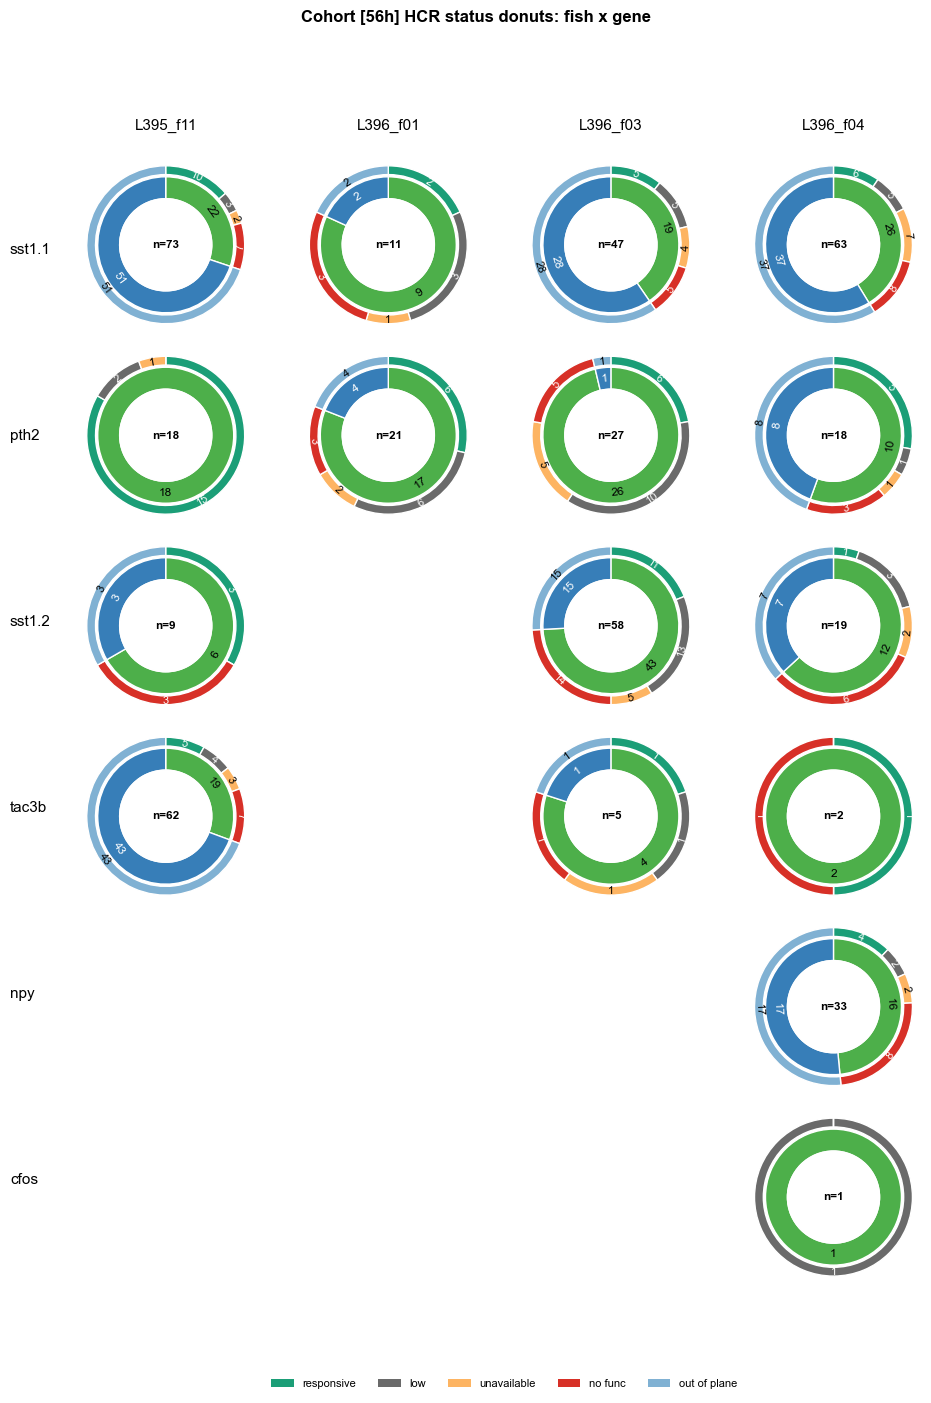

In [8]:
# [cohort-56h-donut-grid] Fish x Gene HCR status donuts (matches [56h] semantics)
from codeants_2pf_hcr.plots.analysis import render_cohort_56h_status_donut_grid
from codeants_2pf_hcr import load_cohort_analysis_state

state_bindings = load_cohort_analysis_state(
    COHORT_BUILD_CONFIG,
    outdir=COHORT_OUTDIR,
    load_tables=True,
    load_trace_cache=False,
    load_cohort_53a_tables=False,
    verbose=True,
)["bindings"]

render_donut_grid = render_cohort_56h_status_donut_grid(
    fish_specs=state_bindings["FISH_SPECS"],
    data_root=state_bindings["DATA_ROOT"],
    data_mode=state_bindings["DATA_MODE"],
    cohort_outdir=state_bindings["COHORT_OUTDIR"],
    cohort_fish_summary_df=state_bindings.get("cohort_fish_summary_df", pd.DataFrame()),
    gene_order=["sst1.1", "pth2", "sst1.2", "tac3b", "npy", "cfos"],
)
COHORT_HCR_DONUT_GRID_LAST = render_donut_grid["fig"]
COHORT_HCR_DONUT_COUNTS_DF = render_donut_grid["counts_df"]
COHORT_HCR_DONUT_FISH_ORDER = render_donut_grid["fish_order"]
COHORT_HCR_DONUT_GENE_ORDER = render_donut_grid["gene_order"]
try:
    COHORT_HCR_DONUT_GRID_LAST.canvas.draw()
    COHORT_HCR_DONUT_GRID_RGBA = np.asarray(COHORT_HCR_DONUT_GRID_LAST.canvas.buffer_rgba()).copy()
except Exception:
    COHORT_HCR_DONUT_GRID_RGBA = None
plt.show()


### [cohort-50l-donut-row] Cohort-wide global response composition by fish
**What goes in:** Each fish's authoritative ROI-centric response and BPI annotations.

**What this does:** Places the fish-level population summaries side by side so you can compare overall response composition across the cohort.

**What comes out:** A row of fish-wise donut summaries plus exported count tables.

**How to interpret it:** Read this figure as a cohort comparison of global population structure rather than a fine-grained gene analysis.

**What good looks like:** The fish differ in understandable ways, but the response classes and stimulus-bias categories remain comparable enough to support cohort-level interpretation.


[cache] no cached cohort outputs loaded from /Users/ddharmap/dataProcessing/2p_HCR/analysis/midThesis/cohort_outputs/multi_fish_56h_56g


,owner,fish_id,n_total,inner__Responsive neurons,inner__Low activity,inner__Response unavailable,outer__bout-responsive,outer__continuous-responsive,outer__both-responsive,outer__weak-response,outer__low activity,outer__response unavailable
0,Matilde,L395_f11,4530,1045,2087,1398,606,250,120,69,2087,1398
1,Matilde,L396_f01,4536,881,1453,2202,663,107,22,89,1453,2202
2,Matilde,L396_f03,3611,326,1405,1880,264,36,9,17,1405,1880
3,Matilde,L396_f04,3633,785,1388,1460,465,215,51,54,1388,1460


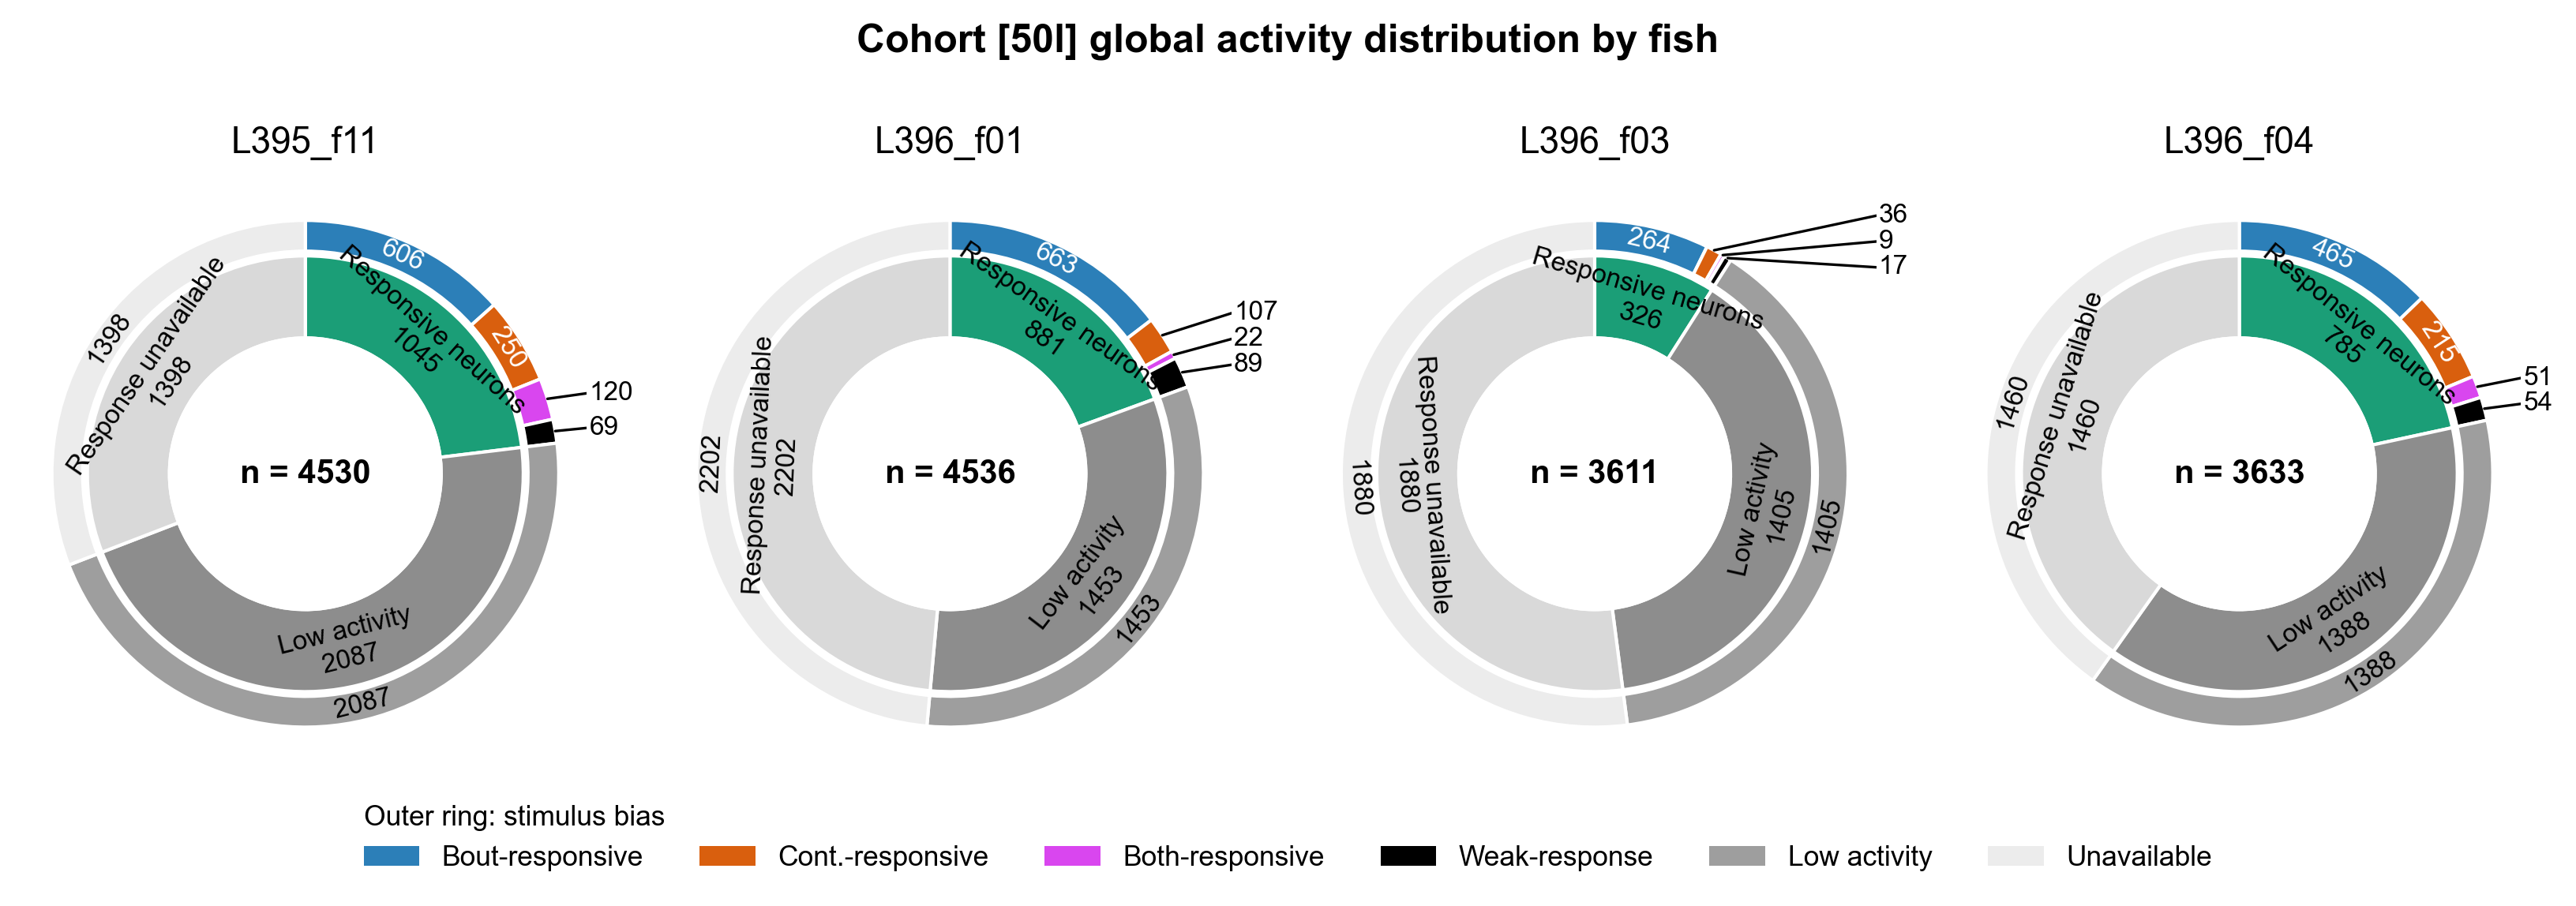

In [9]:
# [cohort-50l-donut-row] Cohort [50l] global activity donuts by fish
from codeants_2pf_hcr.plots.analysis import render_cohort_50l_donut_row
from codeants_2pf_hcr import load_cohort_analysis_state

state_bindings = load_cohort_analysis_state(
    COHORT_BUILD_CONFIG,
    outdir=COHORT_OUTDIR,
    load_tables=False,
    load_trace_cache=False,
    load_cohort_53a_tables=False,
    verbose=True,
)["bindings"]

render_donut_row = render_cohort_50l_donut_row(
    fish_specs=state_bindings["FISH_SPECS"],
    data_root=state_bindings["DATA_ROOT"],
    data_mode=state_bindings["DATA_MODE"],
    cohort_outdir=state_bindings["COHORT_OUTDIR"],
)
COHORT_50L_DONUT_ROW_LAST = render_donut_row["fig"]
COHORT_50L_DONUT_COUNTS_DF = render_donut_row["counts_df"]
COHORT_50L_DONUT_COUNTS_WIDE_DF = render_donut_row["counts_wide_df"]
COHORT_50L_DONUT_FISH_ORDER = render_donut_row["fish_order"]
COHORT_50L_DONUT_LEGEND_LABELS = render_donut_row["legend_labels"]
try:
    COHORT_50L_DONUT_ROW_LAST.canvas.draw()
    COHORT_50L_DONUT_ROW_RGBA = np.asarray(COHORT_50L_DONUT_ROW_LAST.canvas.buffer_rgba()).copy()
except Exception:
    COHORT_50L_DONUT_ROW_RGBA = None
display(COHORT_50L_DONUT_COUNTS_WIDE_DF)
plt.show()
